# One-step propagation demo - *First Method*

This notebook contains the code to recreate Figure 6.1 from J.Schmidt's book. Located in Chapter 6 page 91. For simplified notes to this, check out operator_notation.ipynb. This is the first method where the expansion of the fresnel diffraction integral is performed and only uses a singular Fourier Transform.<br>

The fresnel diffraction integral can be written in operator notation as:
$$
U(\bold{r}_2) = \mathcal{R}[\Delta z,\bold{r}_1,\bold{r}_2]\{U(\bold{r}_1)\} = \mathcal{Q}\left[\frac{1}{\Delta z},\bold{r}_2\right]\mathcal{V}\left[\frac{1}{\lambda \Delta z},\bold{r}_2\right]\mathcal{F}\left[\bold{r}_1,\bold{f}_1\right]\mathcal{Q}\left[\frac{1}{\Delta z},\bold{r}_1\right]\{U(\bold{r}_1)\}
$$
(On how to understand this notation, check out `fresnel_diff_operator_notation.ipynb`)<br>
Note that the grid spacing $\delta_2$ at the observation plane is fixed and is defined as
$$\delta_2 = \frac{\lambda \Delta z}{N \delta_1}$$
However, this is inflexible. There could be a scenario where $\delta_2$ cannot sufficiently sample the observation plane. We can draw a few conclusions from this equation:
- Increasing number of samples $N$, decreases observation plane grid spacing $\delta_2$ (Increases simulation time)
- Increasing source plane grid spacing $\delta_1$, decreases observation plane grid spacing $\delta_2$ (Trade off)
- Wavelength $\lambda$ is typically fixed
- Propagation distance $\Delta z$ is typically fixed

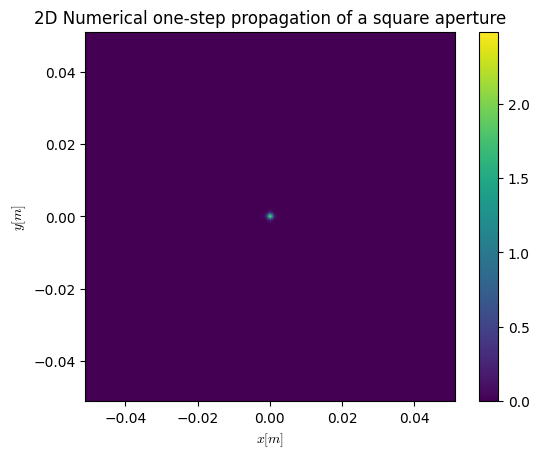

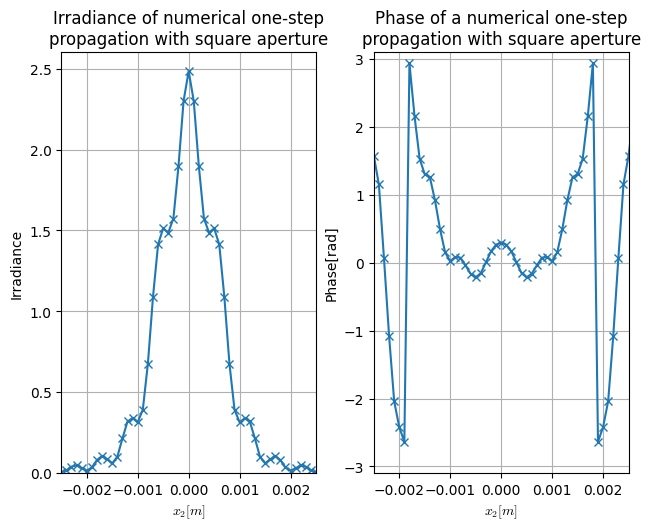

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from optprop.aperture_functions import rect
from optprop.prop import one_step_prop
from textwrap import wrap

# Propagation geometry parameters
N = 1024
L = 1e-2
D = 2e-3
wvl = 1e-6
Dz = 1
d1 = L/N
d2 = (wvl*Dz)/(N*d1)
L2 = d2*N

x = np.arange(-N/2,N/2,1) * d1
x1,y1 = np.meshgrid(x,x)
ap = rect(x1/D) * rect(y1/D)
Uout,x2,y2 = one_step_prop(ap,wvl,d1,Dz)

# 2D Irradiance image of one-step propagation
fig,ax = plt.subplots()
im = ax.imshow(np.abs(Uout)**2,extent=[-L2/2,L2/2,-L2/2,L2/2])
fig.colorbar(im)
ax.set_xlabel(r"$x[m]$",math_fontfamily='cm')
ax.set_ylabel(r"$y[m]$",math_fontfamily='cm')
ax.set_title("2D Numerical one-step propagation of a square aperture")

# 1D Irradiance plot of one-step propagation
fig,ax = plt.subplots(1,2)
fig.tight_layout()
ax[0].plot(x2[0,:],np.abs(Uout[N//2,:])**2,marker='x')
ax[0].set_xlabel(r"$x_2[m]$",math_fontfamily='cm')
ax[0].set_ylabel("Irradiance")
ax[0].set_xlim(-2.5e-3,2.5e-3)
ax[0].set_ylim(0,2.6)
ax[0].set_title("\n".join(wrap("Irradiance of numerical one-step propagation with square aperture",40)))
ax[0].grid(True,'both')

ax[1].plot(x2[0,:],np.angle(Uout[N//2,:]),marker='x')
ax[1].set_xlim(-2.5e-3,2.5e-3)
ax[1].set_ylim(-3.1,3.1)
ax[1].set_xlabel(r"$x_2[m]$",math_fontfamily='cm')
ax[1].set_ylabel("Phase[rad]")
ax[1].set_title("\n".join(wrap("Phase of a numerical one-step propagation with square aperture",40)))
ax[1].grid(True,'both')

plt.show()

The analytical function is not provided in this case. For the analytical function, check J.Schmidt's book.